In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

files = [
    '../results/r8i1_baseline.csv',
    '../results/r8i1_oracle.csv',
    '../results/r8i1_ml_cf_rfc.csv',
    '../results/r8i1_ml_fb_rfc.csv',
]
df = pd.concat([pd.read_csv(f) for f in files])

df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['rv_pending'] = df.revals - df.hit_reval - df.reval_wasted
df['optmiss'] = (df['miss_all'] - df['miss_mandatory']) / df['all'] * 100
df['amp_lower'] = df['reval_wasted'] / (df['miss_all'] + df['hit_reval']) + 1
df['amp_upper'] = (df['reval_wasted'] + df['rv_pending']) / (df['miss_all'] + df['hit_reval']) + 1
df['amp_avg'] = (df['amp_lower'] + df['amp_upper']) / 2
df.head()

,in,gib,ksr,mode,model,mlthres,rv_min_ttl,rv_min_freq,rv_max_za,all,...,miss_evicted,fetches,revals,reval_wasted,miss_all,rv_pending,optmiss,amp_lower,amp_upper,amp_avg
0,fb_c,2048.0,1.0,never,NaN,1.0,0.0,0.0,0.0,96068462.0,...,9726350.0,44300085.0,0.0,0.0,44300085.0,0.0,10.124394,1.0,1.0,1.0
1,fb_b,2048.0,1.0,never,NaN,1.0,0.0,0.0,0.0,102876031.0,...,14859929.0,51802032.0,0.0,0.0,51802032.0,0.0,14.444501,1.0,1.0,1.0
2,wm_t,2048.0,1.0,never,NaN,1.0,0.0,0.0,0.0,197819321.0,...,28975699.0,46870755.0,0.0,0.0,46870755.0,0.0,14.647558,1.0,1.0,1.0
3,fb_a,2048.0,1.0,never,NaN,1.0,0.0,0.0,0.0,50113746.0,...,2213376.0,16919245.0,0.0,0.0,16919245.0,0.0,4.416704,1.0,1.0,1.0
4,fb_a,2048.0,1.0,never,NaN,1.0,0.0,0.0,0.0,50113746.0,...,2213376.0,16919245.0,0.0,0.0,16919245.0,0.0,4.416704,1.0,1.0,1.0


In [2]:
df[df['in'] == 'cf_g'][['mode', 'model', 'mlthres', 'all', 'miss_mandatory', 'miss_evicted', 'miss_expired', 'optmiss', 'revals', 'hit_reval', 'reval_wasted', 'amp_avg']].sort_values('mlthres')

,mode,model,mlthres,all,miss_mandatory,miss_evicted,miss_expired,optmiss,revals,hit_reval,reval_wasted,amp_avg
40,ml,models/v8_cf_rfc.onnx,0.55,305423259.0,30637283.0,10799978.0,0.0,3.536069,3.964969e+09,8920438.0,3.955997e+09,79.558451
36,ml,models/v8_cf_rfc.onnx,0.60,305423259.0,30637283.0,11753550.0,0.0,3.848283,1.004345e+09,7858141.0,9.964522e+08,20.830648
24,ml,models/v8_cf_rfc.onnx,0.65,305423259.0,30637283.0,13038888.0,0.0,4.269121,2.841225e+07,6407820.0,2.198173e+07,1.439124
23,ml,models/v8_cf_rfc.onnx,0.70,305423259.0,30637283.0,14628648.0,0.0,4.789631,6.244006e+06,4602391.0,1.629610e+06,1.032799
25,ml,models/v8_cf_rfc.onnx,0.75,305423259.0,30637283.0,15415063.0,0.0,5.047115,4.530359e+06,3664931.0,8.559100e+05,1.017311
26,ml,models/v8_cf_rfc.onnx,0.80,305423259.0,30637283.0,16823252.0,0.0,5.508176,2.447782e+06,2159238.0,2.816240e+05,1.005745
28,ml,models/v8_cf_rfc.onnx,0.85,305423259.0,30637283.0,17264249.0,0.0,5.652565,1.718124e+06,1600846.0,1.132090e+05,1.002328
27,ml,models/v8_cf_rfc.onnx,0.90,305423259.0,30637283.0,17886777.0,0.0,5.856390,9.015850e+05,870111.0,2.955700e+04,1.000618
29,ml,models/v8_cf_rfc.onnx,0.95,305423259.0,30637283.0,18546147.0,0.0,6.072277,1.417990e+05,139952.0,1.676000e+03,1.000036
31,ml,models/v8_cf_rfc.onnx,1.00,305423259.0,30637283.0,18678572.0,0.0,6.115635,0.000000e+00,0.0,0.000000e+00,1.000000


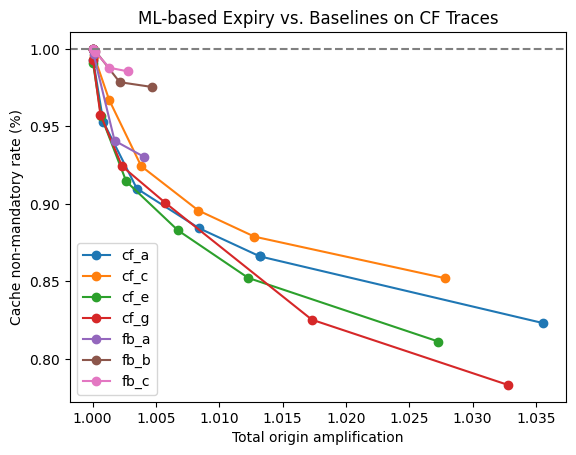

In [7]:
# normalised graph
for s in ['cf_a', 'cf_c', 'cf_e', 'cf_g', 'fb_a', 'fb_b', 'fb_c']:
    df_s = df[(df['in'] == s) & (df['mode'] == 'ml') & (df['amp_avg'] < 1.1)].sort_values('mlthres')
    never_y = df[(df['in'] == s) & (df['mode'] == 'never')]['optmiss']
    never_frac = never_y.values[0]
    plt.plot(df_s['amp_avg'], df_s['optmiss'] / never_frac, marker='o', label=s)

plt.axhline(y=1, color='gray', linestyle='--')
plt.xlabel('Total origin amplification')
plt.ylabel('Cache non-mandatory rate (%)')
plt.title('ML-based Expiry vs. Baselines on CF Traces')
plt.legend()
plt.show()


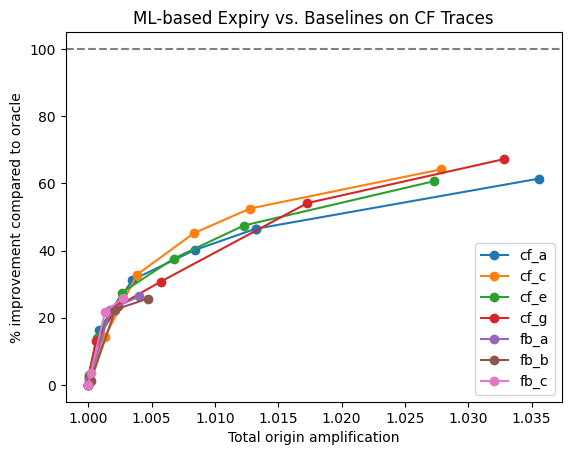

In [10]:
# normalised graph
for s in ['cf_a', 'cf_c', 'cf_e', 'cf_g', 'fb_a', 'fb_b', 'fb_c']:
    df_s = df[(df['in'] == s) & (df['mode'] == 'ml') & (df['amp_avg'] < 1.1)].sort_values('mlthres')
    never_y = df[(df['in'] == s) & (df['mode'] == 'never')]['optmiss']
    oracle_y = df[(df['in'] == s) & (df['mode'] == 'oracle')]['optmiss']
    never_frac = never_y.values[0]
    oracle_frac = oracle_y.max()
    optimal = oracle_frac - never_frac
    plt.plot(df_s['amp_avg'], (df_s['optmiss'] - never_frac)/ optimal * 100, marker='o', label=s)

plt.axhline(y=100, color='gray', linestyle='--')
plt.xlabel('Total origin amplification')
plt.ylabel('% improvement compared to oracle')
plt.title('ML-based Expiry vs. Baselines on CF Traces')
plt.legend()
plt.show()


In [12]:
df['miss_all'] = df['miss_mandatory'] + df['miss_evicted']
df[['revals', 'hit_reval', 'reval_wasted', 'mode']]

,revals,hit_reval,reval_wasted,mode
0,5147885,5141702,6183,oracle
1,5196916,5187066,9850,oracle
2,427244,356732,70512,oracle
3,0,0,0,never
4,0,0,0,never
...,...,...,...,...
82,0,0,0,ml
83,27451775,18274009,8534800,ml
84,33721005,20316764,12494025,ml
85,0,0,0,ml
